### # 📊 Análise de Ações Brasileiras

Este projeto analisa o desempenho de ações brasileiras em comparação ao Ibovespa, avaliando retorno, risco e eficiência de portfólio.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize

tickers = [
    "ALOS3.SA", "BBAS3.SA", "BBSE3.SA",
    "BRBI11.SA", "CMIG4.SA", "CXSE3.SA",
    "LEVE3.SA", "^BVSP"
]

dados = yf.download(tickers, period='5y')['Close']
dados.dropna(inplace=True) # inplace=True para modificar o DataFrame original
display(dados.head())

[*********************100%***********************]  8 of 8 completed


Ticker,ALOS3.SA,BBAS3.SA,BBSE3.SA,BRBI11.SA,CMIG4.SA,CXSE3.SA,LEVE3.SA,^BVSP
Date,,,,,,,,
2021-07-14,24.378239,11.242258,14.512403,13.394511,3.847051,7.819067,16.519659,128407.0
2021-07-15,24.113796,11.070251,14.267385,13.655866,3.809025,7.551808,16.250261,127468.0
2021-07-16,23.783243,10.936090,14.135456,13.590530,3.780506,7.305104,16.199430,125960.0
2021-07-19,23.560122,10.853523,13.903003,13.518654,3.761492,7.078963,15.965616,124395.0
2021-07-20,24.055954,11.046171,13.934417,14.087106,3.847051,7.113226,16.021528,125401.0


In [27]:
# Instalar scipy se não estiver disponível
import subprocess
import sys

try:
    from scipy import stats, optimize
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])

### Tratamento dos Dados

In [4]:
dados_anuais = dados.resample('YE').last()
retornos_anuais = dados_anuais.pct_change().dropna() # pct_change() para calcular os retornos anuais, dropna() para remover valores NaN resultantes do cálculo
display(retornos_anuais)

Ticker,ALOS3.SA,BBAS3.SA,BBSE3.SA,BRBI11.SA,CMIG4.SA,CXSE3.SA,LEVE3.SA,^BVSP
Date,,,,,,,,
2022-12-31,-0.214681,0.349569,0.749028,-0.120191,0.319675,0.077399,0.178321,0.049694
2023-12-31,0.605552,0.734926,0.106964,0.429583,0.151025,0.702136,0.625665,0.219520
2024-12-31,-0.265149,-0.054091,0.159224,-0.020851,0.421753,0.185055,-0.162130,-0.103603
2025-12-31,0.660980,-0.049395,0.122655,0.691954,0.175002,0.271200,0.357507,0.339549
2026-12-31,0.099942,0.078712,0.052762,-0.029500,0.160924,0.134871,0.029610,0.167119


### ANÁLISE EXPLORATÓRIA

In [5]:
# Estatísticas
retornos_anuais.describe()

Ticker,ALOS3.SA,BBAS3.SA,BBSE3.SA,BRBI11.SA,CMIG4.SA,CXSE3.SA,LEVE3.SA,^BVSP
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.177329,0.211944,0.238127,0.190199,0.245676,0.274132,0.205795,0.134456
std,0.439528,0.335140,0.288159,0.352922,0.120016,0.249614,0.302685,0.168984
min,-0.265149,-0.054091,0.052762,-0.120191,0.151025,0.077399,-0.162130,-0.103603
25%,-0.214681,-0.049395,0.106964,-0.029500,0.160924,0.134871,0.029610,0.049694
50%,0.099942,0.078712,0.122655,-0.020851,0.175002,0.185055,0.178321,0.167119
75%,0.605552,0.349569,0.159224,0.429583,0.319675,0.271200,0.357507,0.219520
max,0.660980,0.734926,0.749028,0.691954,0.421753,0.702136,0.625665,0.339549


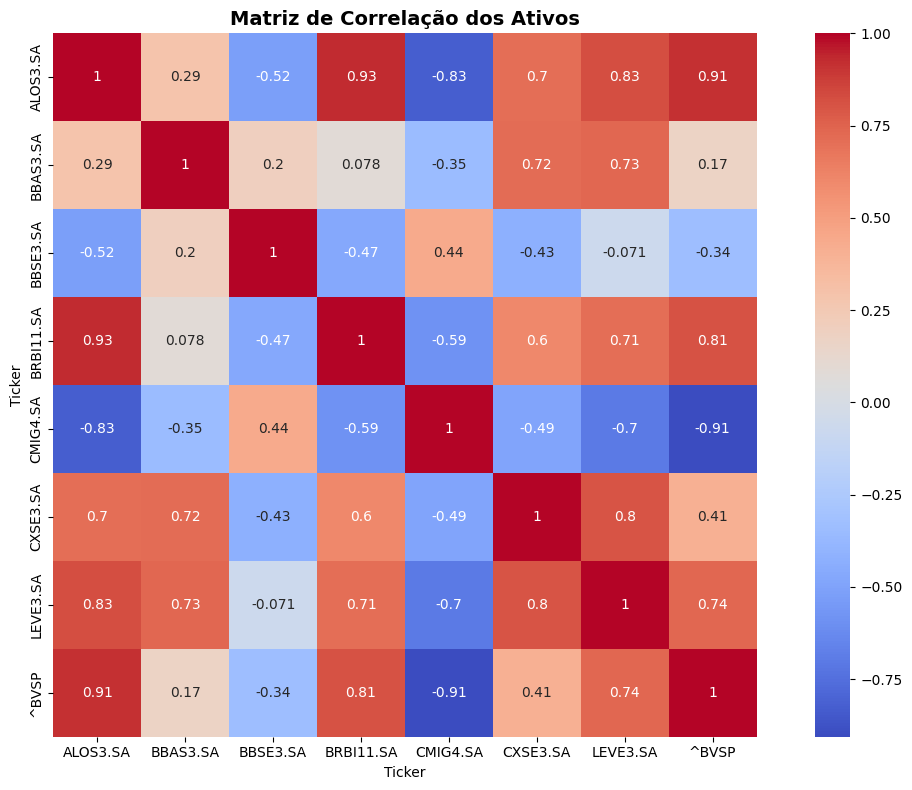

In [6]:
# Correlação
correlacao = retornos_anuais.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', square=True) # annot=True para mostrar os valores, cmap='coolwarm' para uma paleta de cores agradável, square=True para células quadradas
plt.title('Matriz de Correlação dos Ativos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()   
  

In [28]:
# Gerar retornos diários para análises intraanuais
retornos_diarios = dados.pct_change().dropna()

# Análise de Distribuição dos Retornos
skewness = retornos_anuais.skew()
kurtosis = retornos_anuais.kurtosis()

dist_analysis = pd.DataFrame({
    'Assimetria (Skewness)': skewness,
    'Curtose (Kurtosis)': kurtosis
})
display(dist_analysis)

# Skewness < 0: cauda esquerda (mais perdas extremas) | > 0: cauda direita (mais ganhos extremos)
# Kurtosis > 3: caudas pesadas (mais eventos extremos que normal) | < 3: caudas leves


,Assimetria (Skewness),Curtose (Kurtosis)
Ticker,,
ALOS3.SA,0.217510,-2.964982
BBAS3.SA,1.180017,0.437588
BBSE3.SA,2.136643,4.658674
BRBI11.SA,0.854326,-1.532981
CMIG4.SA,0.977241,-1.083477
CXSE3.SA,1.805226,3.428727
LEVE3.SA,0.333801,-0.420488
^BVSP,-0.416452,-0.203231


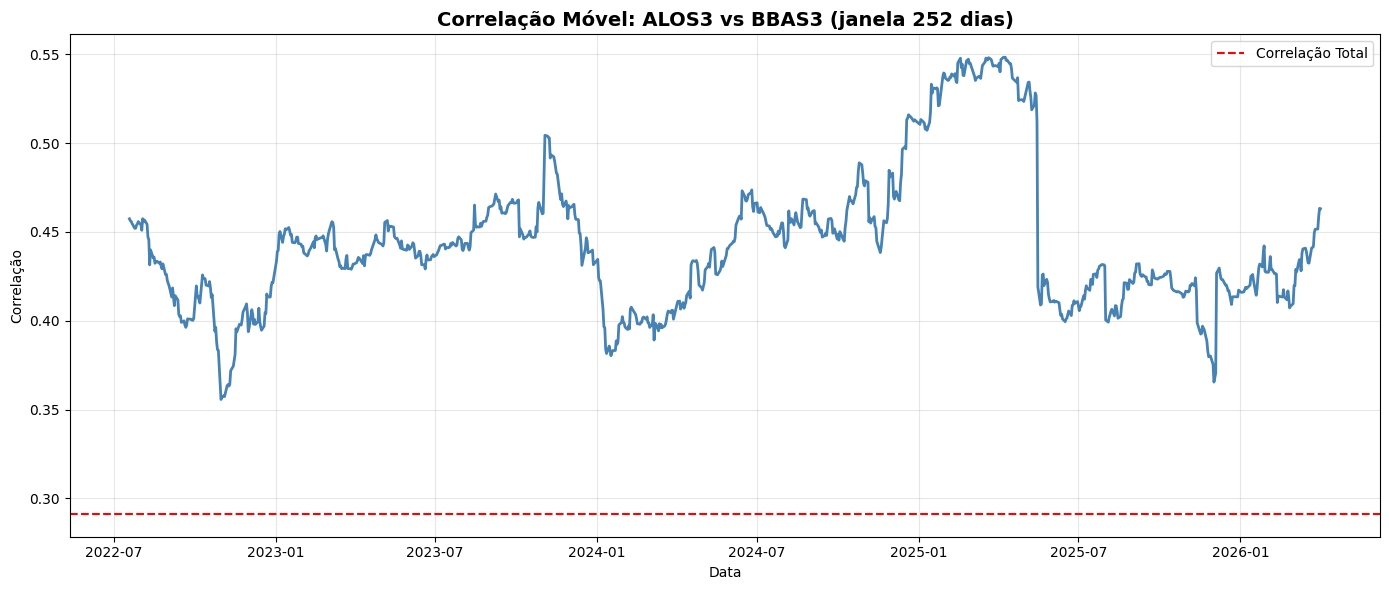

In [29]:
# Rolling Correlation - Correlação ao longo do tempo
# Mostra como as correlações entre ativos mudam ao longo do período
rolling_corr = retornos_diarios[retornos_diarios.columns[:-1]].rolling(window=252).corr()

# Extrair correlação ALOS3 vs BBAS3 ao longo do tempo (exemplo)
if 'ALOS3.SA' in retornos_diarios.columns and 'BBAS3.SA' in retornos_diarios.columns:
    alos_bbas_corr = rolling_corr.unstack()['ALOS3.SA']['BBAS3.SA']
    
    plt.figure(figsize=(14, 6))
    plt.plot(alos_bbas_corr.index, alos_bbas_corr.values, linewidth=2, color='steelblue')
    plt.axhline(y=correlacao.loc['ALOS3.SA', 'BBAS3.SA'], color='red', linestyle='--', label='Correlação Total')
    plt.title('Correlação Móvel: ALOS3 vs BBAS3 (janela 252 dias)', fontsize=14, fontweight='bold')
    plt.ylabel('Correlação')
    plt.xlabel('Data')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Correlações aumentam em crises (flight to quality) e diminuem em períodos normais

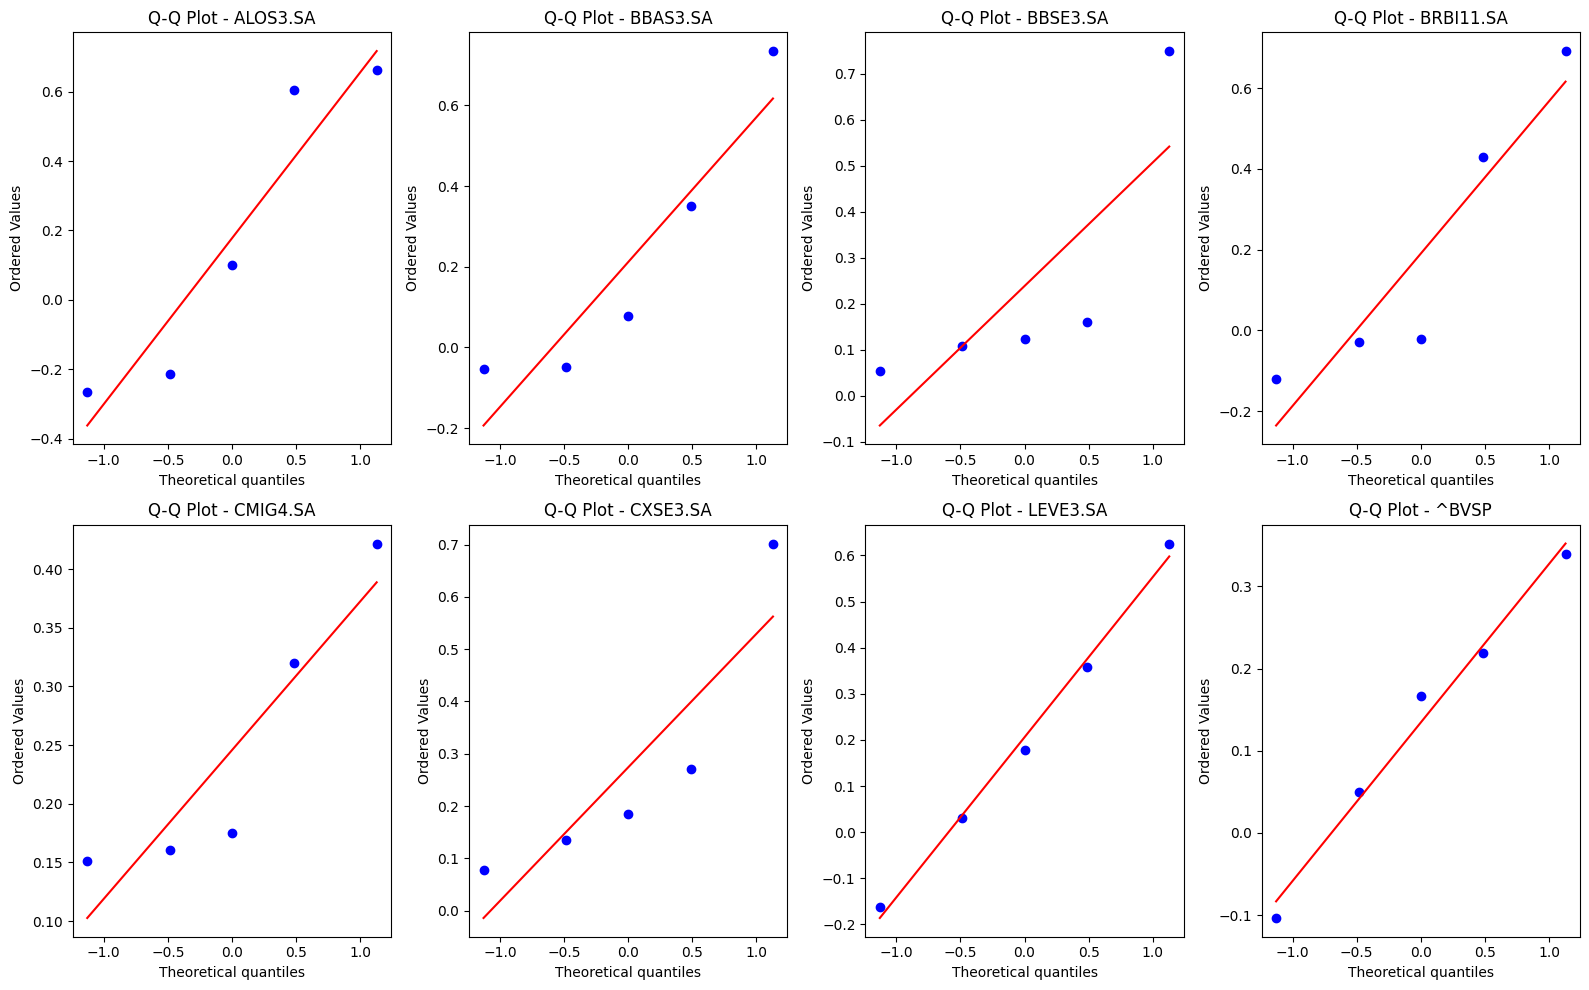

In [30]:
# Q-Q Plot - Teste de Normalidade Visual
from scipy import stats

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, ativo in enumerate(retornos_anuais.columns):
    stats.probplot(retornos_anuais[ativo], dist="norm", plot=axes[idx])
    axes[idx].set_title(f'Q-Q Plot - {ativo}')

plt.tight_layout()
plt.show()

# Pontos próximos à linha diagonal = distribuição normal | Desvios = caudas pesadas (risco de eventos extremos)

### Desempenho

Ticker,ALOS3.SA,BBAS3.SA,BBSE3.SA,BRBI11.SA,CMIG4.SA,CXSE3.SA,LEVE3.SA,^BVSP
Date,,,,,,,,
2022-12-31,0.785319,1.349569,1.749028,0.879809,1.319675,1.077399,1.178321,1.049694
2023-12-31,1.260870,2.341403,1.936112,1.257760,1.518978,1.833878,1.915556,1.280122
2024-12-31,0.926552,2.214754,2.244387,1.231535,2.159612,2.173247,1.604986,1.147498
2025-12-31,1.538985,2.105356,2.519672,2.083700,2.537549,2.762632,2.178780,1.537130
2026-12-31,1.692793,2.271074,2.652614,2.022231,2.945900,3.135230,2.243293,1.794013


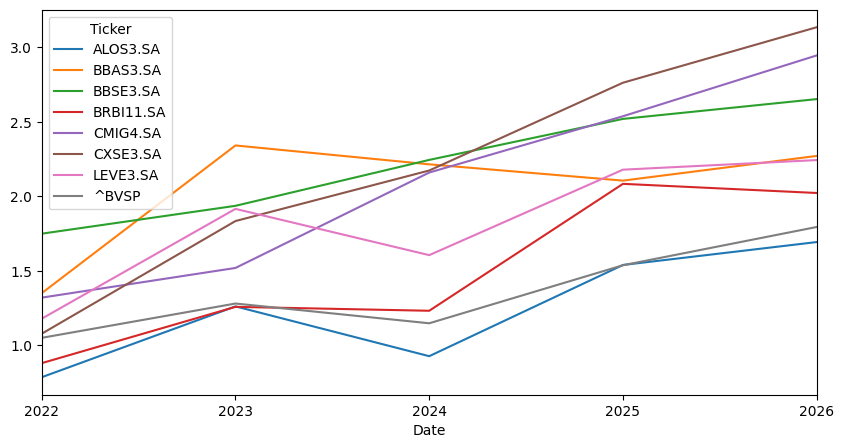

In [31]:
# Retorno acumulativo
retornos_acumulados = (1 + retornos_anuais).cumprod()
retornos_acumulados.plot(figsize=(10,5))

retornos_acumulados = (1 + retornos_anuais).cumprod()
display(retornos_acumulados)

# Retorno acumulado é a evolução do valor de um investimento ao longo do tempo, considerando os retornos periódicos. Ele mostra como o valor do investimento cresce ou diminui ao longo do tempo, 
# levando em conta os ganhos ou perdas acumulados. O retorno acumulado é calculado multiplicando os retornos periódicos sucessivos, o que reflete o efeito de compounding (juros compostos) sobre o investimento.

### Observa-se crescimento consistente em alguns ativos, com destaque para aqueles que superaram o índice de referência.

In [11]:
# Volatilidade
volatilidade = retornos_anuais.std() # Desvio padrão como medida de volatilidade
display(volatilidade)

# Ativos com maior volatilidade apresentam maior risco, podendo oferecer maiores retornos, mas com maior incerteza.

Ticker
ALOS3.SA     0.439528
BBAS3.SA     0.335140
BBSE3.SA     0.288159
BRBI11.SA    0.352922
CMIG4.SA     0.120016
CXSE3.SA     0.249614
LEVE3.SA     0.302685
^BVSP        0.168984
dtype: float64

<Figure size 1400x700 with 0 Axes>

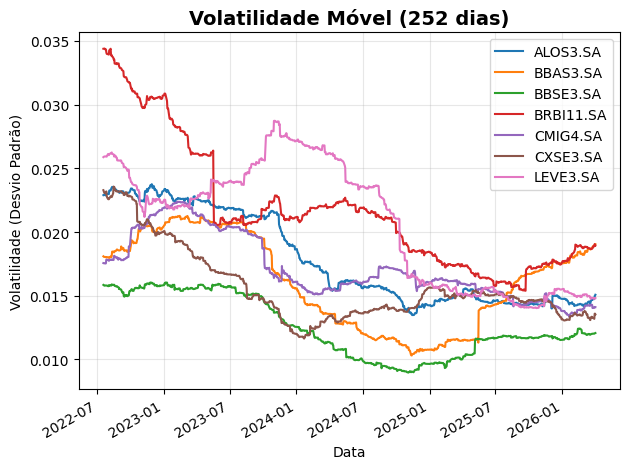

In [32]:
# Rolling Volatility - Volatilidade ao longo do tempo
# Calcula volatilidade em janelas móveis para ver períodos de calma/turbulência
retornos_diarios = dados.pct_change().dropna()
rolling_vol = retornos_diarios[retornos_diarios.columns[:-1]].rolling(window=252).std()  # 252 dias = 1 ano

plt.figure(figsize=(14, 7))
rolling_vol.plot()
plt.title('Volatilidade Móvel (252 dias)', fontsize=14, fontweight='bold')
plt.ylabel('Volatilidade (Desvio Padrão)')
plt.xlabel('Data')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Picos: períodos de maior incerteza/queda | Vales: períodos de estabilidade

In [13]:
# Sharpe
sharpe = retornos_anuais.mean() / retornos_anuais.std()
sharpe.sort_values(ascending=False)
display(sharpe)

# O índice de Sharpe evidencia quais ativos entregam melhor retorno ajustado ao risco.

Ticker
ALOS3.SA     0.403452
BBAS3.SA     0.632406
BBSE3.SA     0.826371
BRBI11.SA    0.538927
CMIG4.SA     2.047020
CXSE3.SA     1.098225
LEVE3.SA     0.679897
^BVSP        0.795670
dtype: float64

In [14]:
# Drawdown
cum = (1 + retornos_anuais).cumprod()
drawdown = cum / cum.cummax() - 1
drawdown.min()
display(drawdown)

# drawdown representa a maior queda percentual do valor do investimento em relação ao seu pico anterior, indicando o risco de perda máxima.

Ticker,ALOS3.SA,BBAS3.SA,BBSE3.SA,BRBI11.SA,CMIG4.SA,CXSE3.SA,LEVE3.SA,^BVSP
Date,,,,,,,,
2022-12-31,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00000,0.000000
2023-12-31,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.00000,0.000000
2024-12-31,-0.265149,-0.054091,0.0,-0.020851,0.0,0.0,-0.16213,-0.103603
2025-12-31,0.000000,-0.100814,0.0,0.000000,0.0,0.0,0.00000,0.000000
2026-12-31,0.000000,-0.030037,0.0,-0.029500,0.0,0.0,0.00000,0.000000


### Risco

In [15]:
# Beta
cov = retornos_anuais.cov()
var_bvsp = retornos_anuais['^BVSP'].var()
beta = cov['^BVSP'] / var_bvsp
display(beta)

# O beta indica a sensibilidade do ativo em relação ao mercado. Beta > 1 indica maior volatilidade que o mercado, enquanto Beta < 1 indica menor volatilidade.

Ticker
ALOS3.SA     2.378298
BBAS3.SA     0.334461
BBSE3.SA    -0.572703
BRBI11.SA    1.686575
CMIG4.SA    -0.643509
CXSE3.SA     0.605298
LEVE3.SA     1.321916
^BVSP        1.000000
Name: ^BVSP, dtype: float64

In [16]:
# VAR
var_95 = retornos_anuais.quantile(0.05) # Quantil de 5% para VaR a 95%
display(var_95)

# O Value at Risk (VaR) a 95% indica a perda máxima esperada em um dia, com 95% de confiança. Por exemplo, um VaR de -0.02 significa que há 5% de chance de perder mais de 2% em um dia.

Ticker
ALOS3.SA    -0.255055
BBAS3.SA    -0.053152
BBSE3.SA     0.063602
BRBI11.SA   -0.102053
CMIG4.SA     0.153004
CXSE3.SA     0.088893
LEVE3.SA    -0.123782
^BVSP       -0.072944
Name: 0.05, dtype: float64

In [17]:
# Sortino Ratio
# Diferente do Sharpe, penaliza apenas volatilidade negativa (downsides)
downside_returns = retornos_anuais[retornos_anuais < 0]
downside_std = downside_returns.std()
sortino = retornos_anuais.mean() / downside_std
display(sortino.sort_values(ascending=False))

# Sortino > Sharpe: avalia melhor apenas o risco que realmente importa (perdas)

Ticker
BBAS3.SA     63.824640
ALOS3.SA      4.969187
BRBI11.SA     3.456432
BBSE3.SA           NaN
CMIG4.SA           NaN
CXSE3.SA           NaN
LEVE3.SA           NaN
^BVSP              NaN
dtype: float64

In [33]:
# Expected Shortfall (CVaR) - Conditional Value at Risk
# Perda média quando o VAR é excedido (pior cenário que 5%)
cvar_95 = retornos_anuais[retornos_anuais <= retornos_anuais.quantile(0.05)].mean()
display(cvar_95)

# CVaR é mais conservador que VaR. Se VaR = -0.10, CVaR pode ser = -0.15, mostrando a perda média que supera o VaR

Ticker
ALOS3.SA    -0.265149
BBAS3.SA    -0.054091
BBSE3.SA     0.052762
BRBI11.SA   -0.120191
CMIG4.SA     0.151025
CXSE3.SA     0.077399
LEVE3.SA    -0.162130
^BVSP       -0.103603
dtype: float64

In [19]:
# Alpha (Retorno Excedente)
# Retorno acima do que o Beta explica
retorno_bvsp = retornos_anuais['^BVSP']
alpha = retornos_anuais.mean() - (0.05 + beta * (retorno_bvsp.mean() - 0.05))  # 5% como taxa livre de risco aproximada
alpha_df = alpha.drop('^BVSP').sort_values(ascending=False)
display(alpha_df)

# Alpha > 0: o ativo superou o esperado pelo seu risco sistêmico (Beta)
# Ativo com Beta=1.2 deveria retornar mais que o mercado, mas se retorna menos, Alpha é negativo

Ticker
CMIG4.SA     0.250024
BBSE3.SA     0.236495
CXSE3.SA     0.173011
BBAS3.SA     0.133697
LEVE3.SA     0.044151
BRBI11.SA   -0.002242
ALOS3.SA    -0.073532
dtype: float64

### BENCHMARK

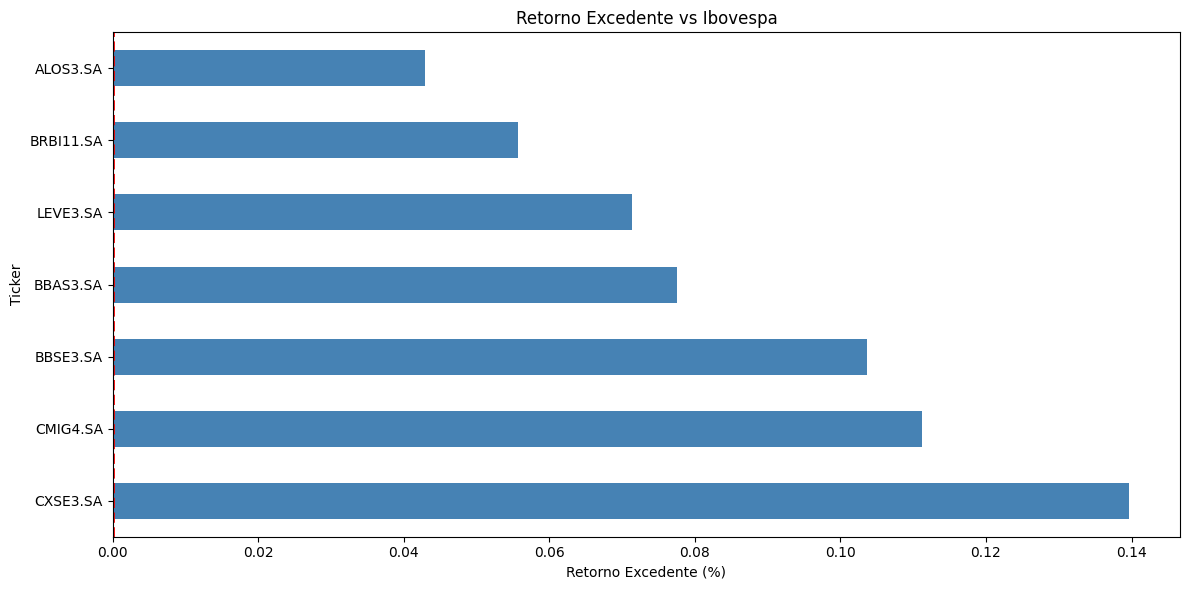

In [20]:
# Excess Return vs Benchmark
excess_return = retornos_anuais.subtract(retornos_anuais['^BVSP'], axis=0).drop('^BVSP', axis=1)
plt.figure(figsize=(12, 6))
excess_return.mean().sort_values(ascending=False).plot(kind='barh', color='steelblue')
plt.xlabel('Retorno Excedente (%)') 
plt.title('Retorno Excedente vs Ibovespa')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.tight_layout()
plt.show()

# Positivo: ativo superou o Ibovespa | Negativo: perdeu para o índice

In [21]:
# Ranking
retornos_anuais.mean().sort_values(ascending=False)

Ticker
CXSE3.SA     0.274132
CMIG4.SA     0.245676
BBSE3.SA     0.238127
BBAS3.SA     0.211944
LEVE3.SA     0.205795
BRBI11.SA    0.190199
ALOS3.SA     0.177329
^BVSP        0.134456
dtype: float64

## PORTFÓLIO (DIFERENCIAL)

In [22]:
retorno_esperado = retornos_anuais.mean()
cov_matrix = retornos_anuais.cov()

pesos = np.random.random(len(retornos_anuais.columns))
pesos /= np.sum(pesos)

retorno_port = np.dot(pesos, retorno_esperado)
risco_port = np.sqrt(np.dot(pesos.T, np.dot(cov_matrix, pesos)))
print(f"Retorno esperado do portfólio: {retorno_port:.4f}")
print(f"Risco do portfólio: {risco_port:.4f}")

Retorno esperado do portfólio: 0.2107
Risco do portfólio: 0.1931


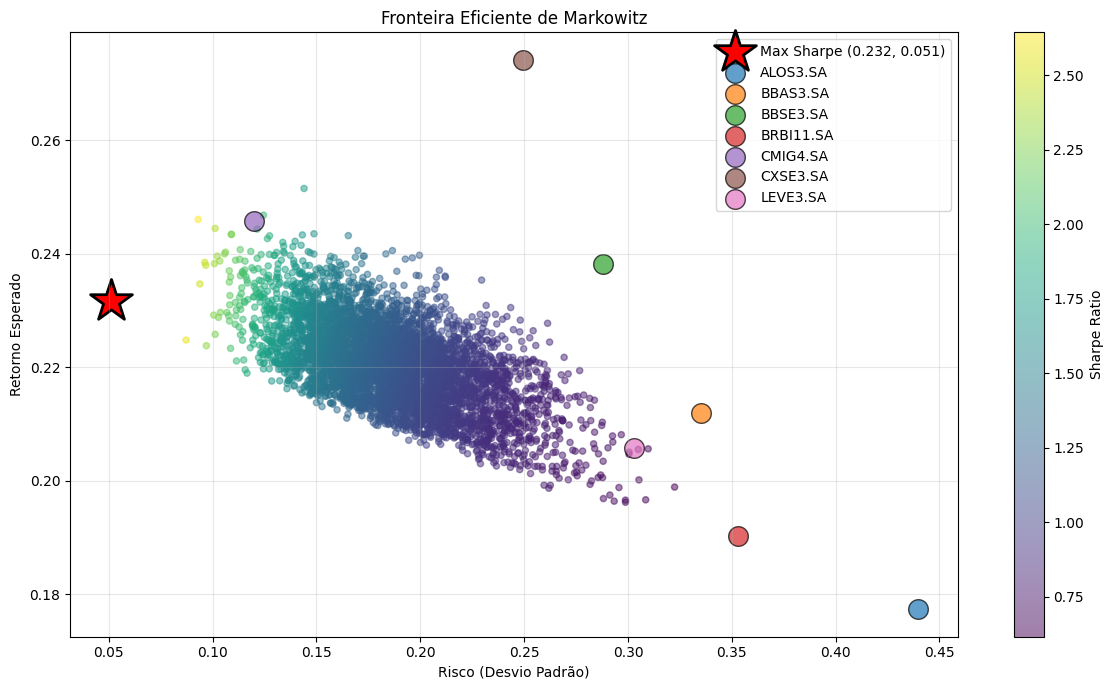


=== PORTFÓLIO COM MÁXIMO SHARPE RATIO ===


,Ativo,Peso (%)
4,CMIG4.SA,74.820278
0,ALOS3.SA,18.101455
1,BBAS3.SA,4.055403
2,BBSE3.SA,3.022864
3,BRBI11.SA,0.000000
5,CXSE3.SA,0.000000
6,LEVE3.SA,0.000000



Retorno Esperado: 0.2317 (23.17%)
Risco (Volatilidade): 0.0508 (5.08%)
Sharpe Ratio: 4.5605


In [34]:
# Efficient Frontier - Fronteira Eficiente de Markowitz
from scipy.optimize import minimize

# Remove Ibovespa para análise de portfólio
ativos = retornos_anuais.drop('^BVSP', axis=1)
retorno_esperado = ativos.mean()
cov_matrix = ativos.cov()

# Função para calcular retorno e risco do portfólio
def portfolio_performance(weights):
    retorno = np.sum(retorno_esperado * weights)
    risco = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return retorno, risco

# Função para minimizar (negativo do Sharpe para maximizar)
def negative_sharpe(weights):
    p_ret, p_risk = portfolio_performance(weights)
    return -(p_ret / p_risk)

# Restrições e limites
constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
bounds = tuple((0, 1) for _ in range(len(ativos.columns)))
init_guess = np.array([1/len(ativos.columns)] * len(ativos.columns))

# Otimizar para Maximum Sharpe Ratio
opt_sharpe = minimize(negative_sharpe, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
max_sharpe_weights = opt_sharpe.x
max_sharpe_ret, max_sharpe_risk = portfolio_performance(max_sharpe_weights)

# Gerar pontos da fronteira eficiente
portfolios = []
for _ in range(5000):
    pesos = np.random.random(len(ativos.columns))
    pesos /= np.sum(pesos)
    ret, risk = portfolio_performance(pesos)
    portfolios.append([ret, risk])

portfolios = np.array(portfolios)

# Plotar Efficient Frontier
plt.figure(figsize=(12, 7))
plt.scatter(portfolios[:, 1], portfolios[:, 0], c=portfolios[:, 0]/portfolios[:, 1], cmap='viridis', alpha=0.5, s=20)
plt.colorbar(label='Sharpe Ratio')

# Marcar portfólios ótimos
plt.scatter(max_sharpe_risk, max_sharpe_ret, marker='*', color='red', s=1000, edgecolors='black', linewidth=2, label=f'Max Sharpe ({max_sharpe_ret:.3f}, {max_sharpe_risk:.3f})')

# Plotar ativos individuais
for ativo in ativos.columns:
    idx = ativos.columns.get_loc(ativo)
    plt.scatter(ativos[ativo].std(), ativos[ativo].mean(), s=200, alpha=0.7, label=ativo, edgecolors='black', linewidth=1)

plt.xlabel('Risco (Desvio Padrão)')
plt.ylabel('Retorno Esperado')
plt.title('Fronteira Eficiente de Markowitz')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Pesos do portfólio ótimo
print("\n=== PORTFÓLIO COM MÁXIMO SHARPE RATIO ===")
optimal_allocation = pd.DataFrame({
    'Ativo': ativos.columns,
    'Peso (%)': max_sharpe_weights * 100
}).sort_values('Peso (%)', ascending=False)
display(optimal_allocation)
print(f"\nRetorno Esperado: {max_sharpe_ret:.4f} ({max_sharpe_ret*100:.2f}%)")
print(f"Risco (Volatilidade): {max_sharpe_risk:.4f} ({max_sharpe_risk*100:.2f}%)")
print(f"Sharpe Ratio: {max_sharpe_ret/max_sharpe_risk:.4f}")

In [35]:
# Portfólio de Mínima Variância
def portfolio_variance(weights):
    return np.dot(weights.T, np.dot(cov_matrix, weights))

opt_variance = minimize(portfolio_variance, init_guess, method='SLSQP', bounds=bounds, constraints=constraints)
min_var_weights = opt_variance.x
min_var_ret, min_var_risk = portfolio_performance(min_var_weights)

print("\n=== PORTFÓLIO DE MÍNIMA VARIÂNCIA ===")
min_var_allocation = pd.DataFrame({
    'Ativo': ativos.columns,
    'Peso (%)': min_var_weights * 100
}).sort_values('Peso (%)', ascending=False)
display(min_var_allocation)
print(f"\nRetorno Esperado: {min_var_ret:.4f} ({min_var_ret*100:.2f}%)")
print(f"Risco (Volatilidade): {min_var_risk:.4f} ({min_var_risk*100:.2f}%)")
print(f"Sharpe Ratio: {min_var_ret/min_var_risk:.4f}")

# O portfólio de mínima variância prioriza segurança sobre retorno, ideal para investidores conservadores


=== PORTFÓLIO DE MÍNIMA VARIÂNCIA ===


,Ativo,Peso (%)
4,CMIG4.SA,7.447515e+01
0,ALOS3.SA,1.833222e+01
1,BBAS3.SA,4.006308e+00
2,BBSE3.SA,3.186326e+00
6,LEVE3.SA,7.283179e-16
3,BRBI11.SA,0.000000e+00
5,CXSE3.SA,0.000000e+00



Retorno Esperado: 0.2316 (23.16%)
Risco (Volatilidade): 0.0508 (5.08%)
Sharpe Ratio: 4.5594


In [36]:
# Comparação: Equal Weight vs Portfólios Otimizados
# Equal Weight = todos os ativos com igual peso
equal_weights = np.array([1/len(ativos.columns)] * len(ativos.columns))
eq_ret, eq_risk = portfolio_performance(equal_weights)

# Tabela comparativa
comparison = pd.DataFrame({
    'Estratégia': ['Equal Weight', 'Máximo Sharpe', 'Mínima Variância'],
    'Retorno (%)': [eq_ret*100, max_sharpe_ret*100, min_var_ret*100],
    'Risco (%)': [eq_risk*100, max_sharpe_risk*100, min_var_risk*100],
    'Sharpe Ratio': [eq_ret/eq_risk, max_sharpe_ret/max_sharpe_risk, min_var_ret/min_var_risk]
})
display(comparison)

print("\n💡 Insight:")
if max_sharpe_ret/max_sharpe_risk > eq_ret/eq_risk:
    print(f"Portfólio otimizado tem Sharpe {(max_sharpe_ret/max_sharpe_risk)/(eq_ret/eq_risk):.2f}x melhor que Equal Weight!")
else:
    print("Equal Weight oferece melhor retorno ajustado ao risco neste caso.")

,Estratégia,Retorno (%),Risco (%),Sharpe Ratio
0,Equal Weight,22.045729,18.165568,1.213600
1,Máximo Sharpe,23.170774,5.080748,4.560504
2,Mínima Variância,23.155424,5.078660,4.559357



💡 Insight:
Portfólio otimizado tem Sharpe 3.76x melhor que Equal Weight!


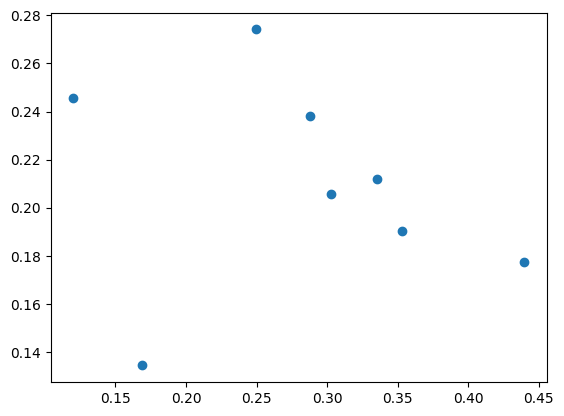

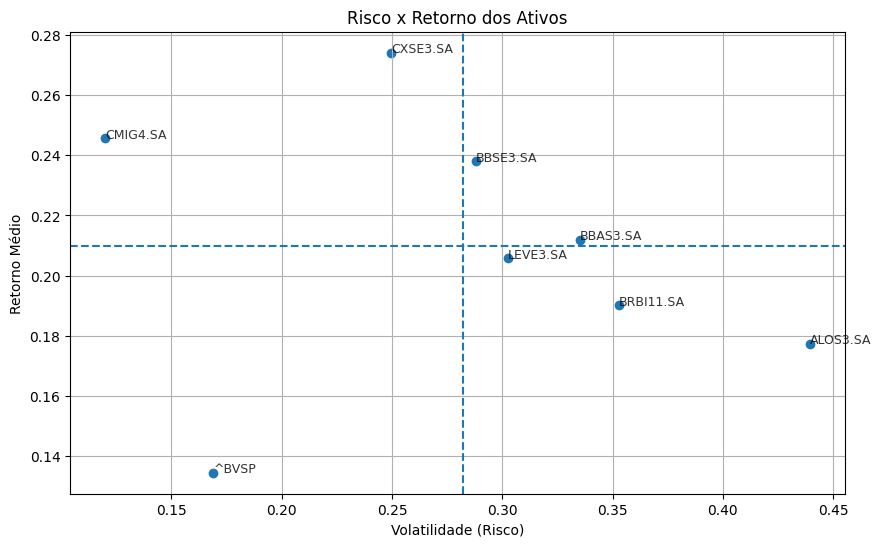

In [37]:
# GRÁFICO RISCO x RETORNO

plt.scatter(volatilidade, retornos_anuais.mean())

media_retornos = retornos_anuais.mean()

plt.figure(figsize=(10,6))

# Scatter
plt.scatter(volatilidade, media_retornos)

# Labels dos pontos
for ativo in retornos_anuais.columns:
    plt.annotate(
        ativo,
        (volatilidade.loc[ativo], media_retornos.loc[ativo]),
        fontsize=9,
        alpha=0.8
    )

# Linha vertical (risco médio)
plt.axvline(volatilidade.mean(), linestyle='--')

# Linha horizontal (retorno médio)
plt.axhline(media_retornos.mean(), linestyle='--')

# Títulos e labels
plt.title('Risco x Retorno dos Ativos')
plt.xlabel('Volatilidade (Risco)')
plt.ylabel('Retorno Médio')

plt.grid(True)
plt.show()